In [1]:
# Import required libraries
import pandas as pd
import json
from sqlalchemy import create_engine

In [2]:
# Define the database path
DB_PATH = "../data/names2.db"

# Create a connection to the SQLite database
engine = create_engine(f"sqlite:///{DB_PATH}")

In [3]:
# Load the `names` table into a Pandas DataFrame
df = pd.read_sql("SELECT * FROM names", engine)

# Convert the 'full_countries_distribution' column back to a dictionary
df["full_countries_distribution"] = df["full_countries_distribution"].apply(json.loads)

# Display the first few rows of the DataFrame
df.head()

,name,full_countries_distribution,top_country,top_country_prob,strong_top_country,agreement_score,n_models_used
0,A A,"{'Afghanistan': None, 'Albania': None, 'Algeri...",Bangladesh,0.329,0,None,0
1,A A A,"{'Afghanistan': None, 'Albania': None, 'Algeri...",Bangladesh,0.714,1,None,0
2,A A Ron,"{'Afghanistan': None, 'Albania': None, 'Algeri...",United States,0.615,0,None,0
3,A Abdiel,"{'Afghanistan': None, 'Albania': None, 'Algeri...",Panama,1.000,1,None,0
4,A Abera,"{'Afghanistan': None, 'Albania': None, 'Algeri...",Ethiopia,1.000,1,None,0


In [4]:
# Count the number of names with a strong top country
df_strong_top = pd.read_sql(
    "SELECT COUNT(*) AS strong_top_count FROM names WHERE strong_top_country", engine
)

# Display the result
df_strong_top

,strong_top_count
0,339711


<Axes: title={'center': 'Top 20 Countries by Name Count'}, xlabel='Country'>

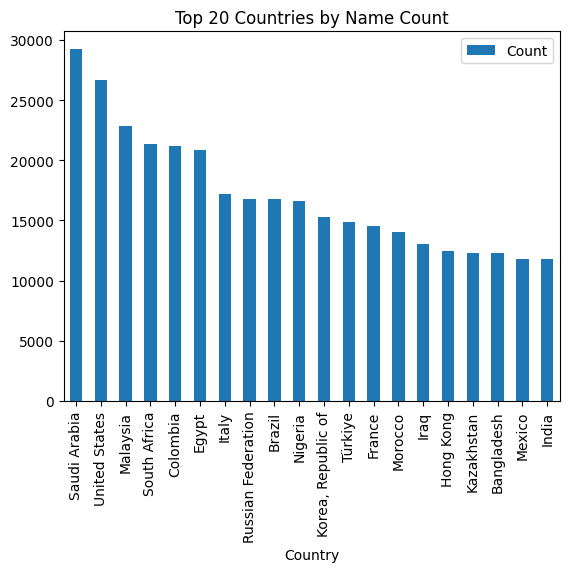

In [20]:
# Visualize the top countries by name count
top_countries = (
    df["top_country"]
    .value_counts()
    .head(20)
    .rename_axis("Country")      # names the index
    .reset_index(name="Count")   # names the values column
)

top_countries.plot(
    kind="bar",
    x="Country",
    y="Count",
    title="Top 20 Countries by Name Count"
)


In [6]:
mean_prob_by_country = (
    df
    .groupby("top_country", as_index=False)
    .agg(
        mean_top_country_prob=("top_country_prob", "mean"),
        count=("top_country", "size")
    )
)

mean_prob_by_country.head()


,top_country,mean_top_country_prob,count
0,Afghanistan,0.605058,8296
1,Albania,0.646554,7690
2,Algeria,0.588429,11173
3,Angola,0.733686,6371
4,Argentina,0.499304,4463


In [7]:
top20_country_mean_prob = (
    df
    .groupby("top_country")
    .agg(
        Count=("top_country", "size"),
        Mean_Prob=("top_country_prob", "mean")
    )
    .sort_values("Count", ascending=False)
    .head(20)
    .reset_index()
)

top20_country_mean_prob


,top_country,Count,Mean_Prob
0,Saudi Arabia,29251,0.405247
1,United States,26660,0.430528
2,Malaysia,22879,0.570180
3,South Africa,21320,0.721138
4,Colombia,21213,0.543248
5,Egypt,20884,0.571760
6,Italy,17215,0.556834
7,Russian Federation,16782,0.740573
8,Brazil,16775,0.699193
9,Nigeria,16598,0.797551


<Axes: title={'center': 'Mean Top-Country Probability (Top 20 Countries)'}, xlabel='top_country'>

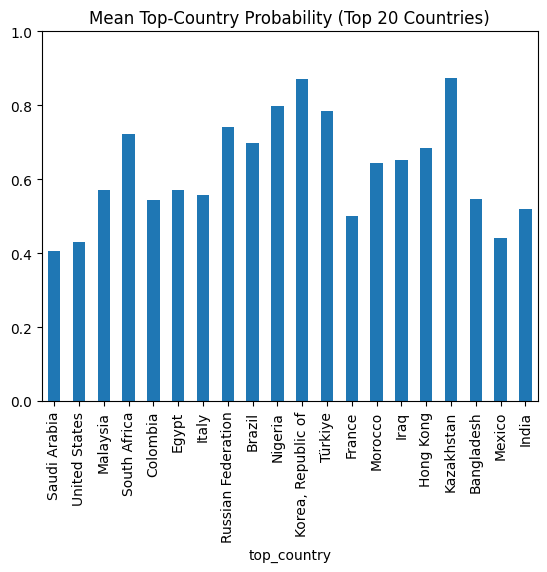

In [8]:
top20_country_mean_prob.plot(
    kind="bar",
    x="top_country",
    y="Mean_Prob",
    title="Mean Top-Country Probability (Top 20 Countries)",
    ylim=(0, 1),
    legend=False
)


Text(0.5, 1.0, 'Top Countries: Frequency vs Confidence')

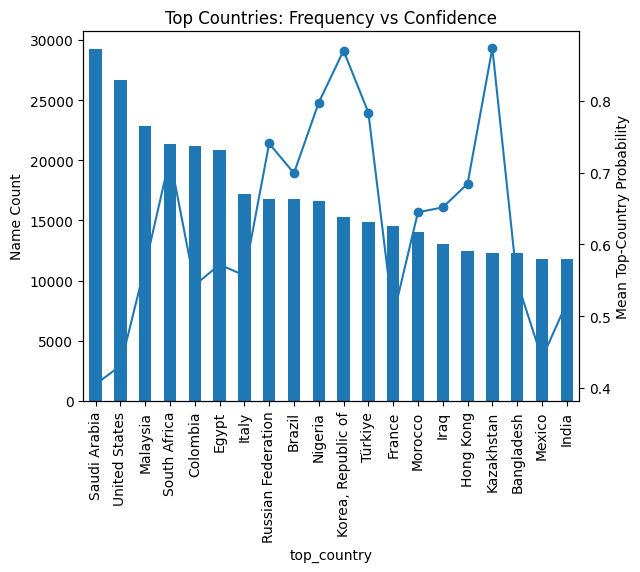

In [9]:
ax = top20_country_mean_prob.plot(
    kind="bar",
    x="top_country",
    y="Count",
    legend=False
)

ax2 = ax.twinx()
top20_country_mean_prob.plot(
    kind="line",
    x="top_country",
    y="Mean_Prob",
    marker="o",
    ax=ax2,
    legend=False
)

ax.set_ylabel("Name Count")
ax2.set_ylabel("Mean Top-Country Probability")
ax.set_title("Top Countries: Frequency vs Confidence")


In [10]:
top10_strong_only = (
    df[df["strong_top_country"] == True]
    .groupby("top_country")
    .agg(
        Count=("top_country", "size"),
        Mean_Prob=("top_country_prob", "mean")
    )
    .sort_values("Count", ascending=False)
    .head(10)
    .reset_index()
)

top10_strong_only


,top_country,Count,Mean_Prob
0,South Africa,12239,0.932199
1,"Korea, Republic of",12163,0.961133
2,Nigeria,12143,0.928629
3,Russian Federation,10746,0.868580
4,Türkiye,10606,0.911276
5,Kazakhstan,10082,0.952332
6,Brazil,9380,0.895964
7,Hungary,8859,0.973820
8,Lithuania,8116,0.986393
9,Malaysia,7501,0.876965


<Axes: title={'center': "Top 10 Most Confidently Predicted Countries' Mean Probability"}, xlabel='top_country'>

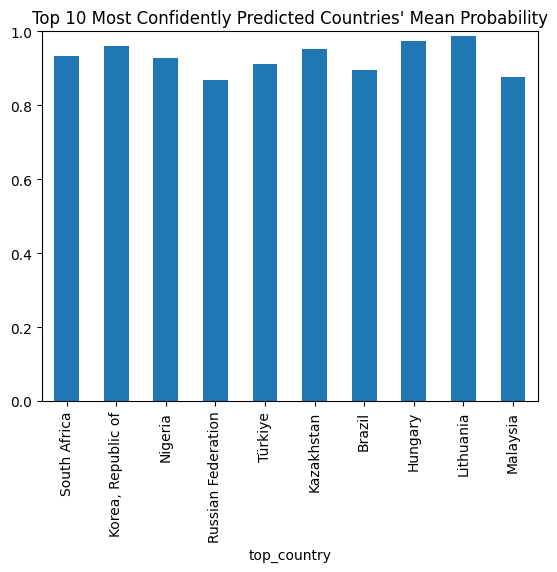

In [11]:
top10_strong_only.plot(
    kind="bar",
    x="top_country",
    y="Mean_Prob",
    title="Top 10 Most Confidently Predicted Countries' Mean Probability",
    ylim=(0, 1),
    legend=False
)


In [12]:
country_stats = (
    df
    .groupby("top_country")
    .agg(
        name_count=("top_country", "size"),
        mean_prob=("top_country_prob", "mean")
    )
    .reset_index()
)

country_stats.head()


,top_country,name_count,mean_prob
0,Afghanistan,8296,0.605058
1,Albania,7690,0.646554
2,Algeria,11173,0.588429
3,Angola,6371,0.733686
4,Argentina,4463,0.499304


Text(0, 0.5, 'Mean Top-Country Probability')

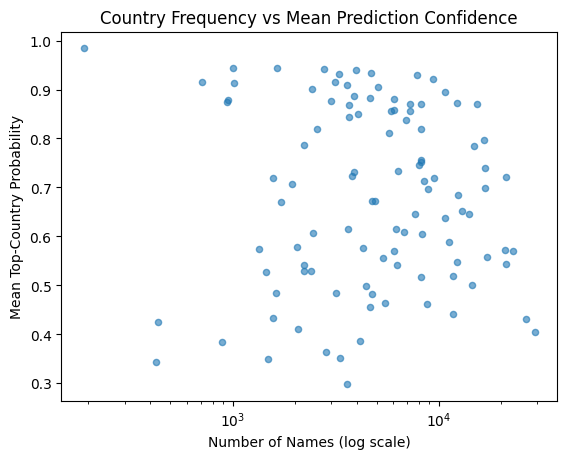

In [13]:
ax = country_stats.plot(
    kind="scatter",
    x="name_count",
    y="mean_prob",
    title="Country Frequency vs Mean Prediction Confidence",
    alpha=0.6
)

ax.set_xscale("log")
ax.set_xlabel("Number of Names (log scale)")
ax.set_ylabel("Mean Top-Country Probability")


Text(0, 0.5, 'Mean Top-Country Probability')

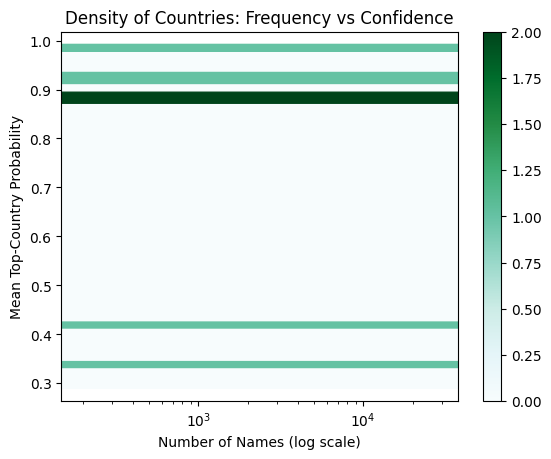

In [14]:
ax = country_stats.plot(
    kind="hexbin",
    x="name_count",
    y="mean_prob",
    gridsize=30,
    title="Density of Countries: Frequency vs Confidence"
)

ax.set_xscale("log")
ax.set_xlabel("Number of Names (log scale)")
ax.set_ylabel("Mean Top-Country Probability")


In [15]:
top_guess_counts = (
    df["top_country"]
    .value_counts()
    .rename_axis("Country")
    .reset_index(name="Top_Guess_Count")
)

top_guess_counts.head()


,Country,Top_Guess_Count
0,Saudi Arabia,29251
1,United States,26660
2,Malaysia,22879
3,South Africa,21320
4,Colombia,21213


Text(0, 0.5, 'Mean Top-Country Probability')

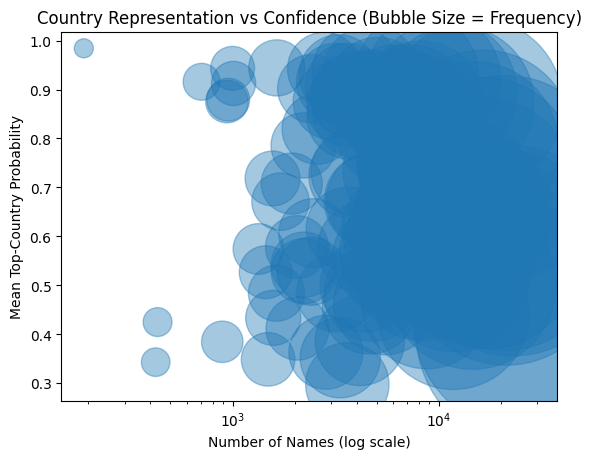

In [16]:
ax = country_stats.plot(
    kind="scatter",
    x="name_count",
    y="mean_prob",
    s=country_stats["name_count"],
    alpha=0.4,
    title="Country Representation vs Confidence (Bubble Size = Frequency)"
)

ax.set_xscale("log")
ax.set_xlabel("Number of Names (log scale)")
ax.set_ylabel("Mean Top-Country Probability")


In [17]:
country_stats["freq_bin"] = pd.qcut(
    country_stats["name_count"],
    q=4,
    labels=["Very Low", "Low", "Medium", "High"]
)

country_stats.head()


,top_country,name_count,mean_prob,freq_bin
0,Afghanistan,8296,0.605058,Medium
1,Albania,7690,0.646554,Medium
2,Algeria,11173,0.588429,High
3,Angola,6371,0.733686,Medium
4,Argentina,4463,0.499304,Low


Text(0, 0.5, 'Mean Top-Country Probability')

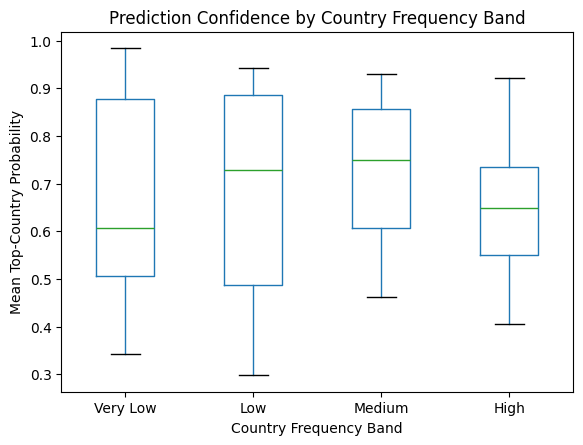

In [19]:
import matplotlib.pyplot as plt

country_stats.boxplot(
    column="mean_prob",
    by="freq_bin",
    grid=False
)

plt.title("Prediction Confidence by Country Frequency Band")
plt.suptitle("")
plt.xlabel("Country Frequency Band")
plt.ylabel("Mean Top-Country Probability")


Text(0, 0.5, 'Mean Top-Country Probability ± SD')

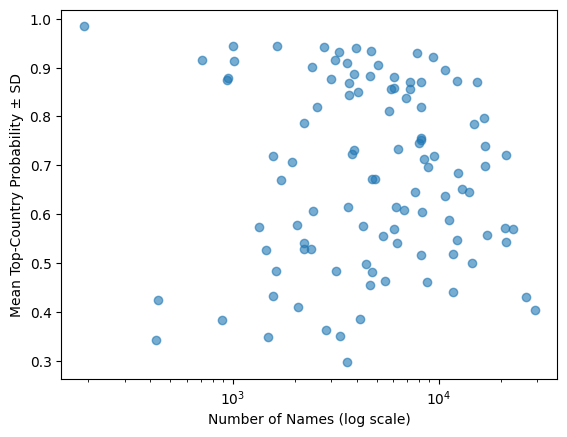

In [23]:
plt.errorbar(
    country_stats['name_count'],
    country_stats['mean_prob'],
    # yerr=country_stats['prob_std'],  # optional
    fmt='o',
    alpha=0.6
)
plt.xscale('log')
plt.xlabel("Number of Names (log scale)")
plt.ylabel("Mean Top-Country Probability ± SD")
